# Phase 2 — Clause segmentation

## Goal

**How do we split long contracts into smaller units (clauses / segments)?**

### Problem

- CUAD contracts are **long** single documents; downstream models (BERT) have **finite context**.
- Legal structure is only **partially** reflected in plain text (PDFs / OCR make this harder later).

### Approach (initial)

**Rule-based segmentation** as a reproducible baseline before learned segmenters:

1. **Newlines** — paragraph and line breaks often align with blocks.
2. **Punctuation** — split on sentence boundaries (`.;:`) within merged lines.
3. **Headings** — lines that look like `Section …`, `Article …`, numbered headings, or short **ALL CAPS** titles become their own segments.

Implementation: `src/phase2/segmentation/clause_splitter.split_clauses`.


In [1]:
from __future__ import annotations

import sys
from pathlib import Path

import matplotlib.pyplot as plt

PROJECT_ROOT = Path("../..").resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.phase2.segmentation.clause_splitter import split_clauses

TXT_DIR = PROJECT_ROOT / "data" / "CUAD_v1" / "full_contract_txt"
sample = sorted(TXT_DIR.glob("*.txt"))[0]
raw = sample.read_text(encoding="utf-8", errors="replace")
segments = split_clauses(raw)
print("Sample file:", sample.name)
print("Characters (raw):", len(raw), "| Segments:", len(segments))


Sample file: 2ThemartComInc_19990826_10-12G_EX-10.10_6700288_EX-10.10_Co-Branding Agreement_ Agency Agreement.txt
Characters (raw): 29454 | Segments: 266


### Before vs after

- **Before:** one long string (show a short prefix so the notebook stays readable).
- **After:** list of segments; inspect counts and a length histogram.


=== BEFORE (prefix) ===
CO-BRANDING AND ADVERTISING AGREEMENT

THIS CO-BRANDING AND ADVERTISING AGREEMENT (the "Agreement") is made as of June 21, 1999 (the "Effective Date") by and between I-ESCROW, INC., with its principal place of business at 1730 S. Amphlett Blvd., Suite 233, San Mateo, California 94402 ("i-Escrow"), and 2THEMART.COM, INC. having its principal place of business at 18301 Von Karman Avenue, 7th Floor, Irvine, California 92612 ("2TheMart").

1. DEFINITIONS.

(a) "CONTENT" means all content or information, in any medium, provided by a party to the other party for use in conjunction with the performance of its obligations hereunder, including without limitation any text, music, sound, photographs, video, graphics, data or software. Content provided by 2TheMart is referred to herein as "2TheMart Content" and Content provided by i-Escrow is referred to herein as "i-Escrow Content."

(b) "CO-BRANDE

=== AFTER (first 12 segments) ===
[0] (37 chars) CO-BRANDING AND ADVERTISI

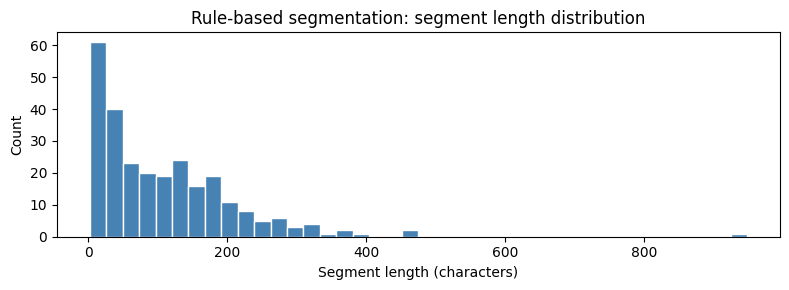

In [2]:
PREVIEW_CHARS = 900
print("=== BEFORE (prefix) ===")
print(raw[:PREVIEW_CHARS])
print("\n=== AFTER (first 12 segments) ===")
for i, seg in enumerate(segments[:12]):
    print(f"[{i}] ({len(seg)} chars)", seg[:200].replace("\n", " ") + ("…" if len(seg) > 200 else ""))

lens = [len(s) for s in segments]
fig, ax = plt.subplots(figsize=(8, 3))
ax.hist(lens, bins=40, color="steelblue", edgecolor="white")
ax.set_xlabel("Segment length (characters)")
ax.set_ylabel("Count")
ax.set_title("Rule-based segmentation: segment length distribution")
plt.tight_layout()
plt.show()
